# First Data Analysis
Visualization of distribution in the dataset

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


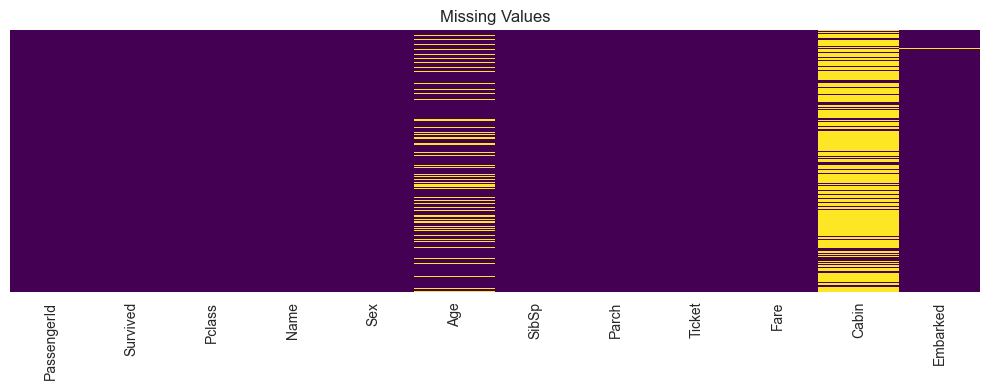

How many missing values in every column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [45]:
# Missing values heatmap

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values')
plt.tight_layout()
plt.savefig('../plots/missing_values.png', dpi = 450)
plt.show()

print('How many missing values in every column:')
print(df.isnull().sum())

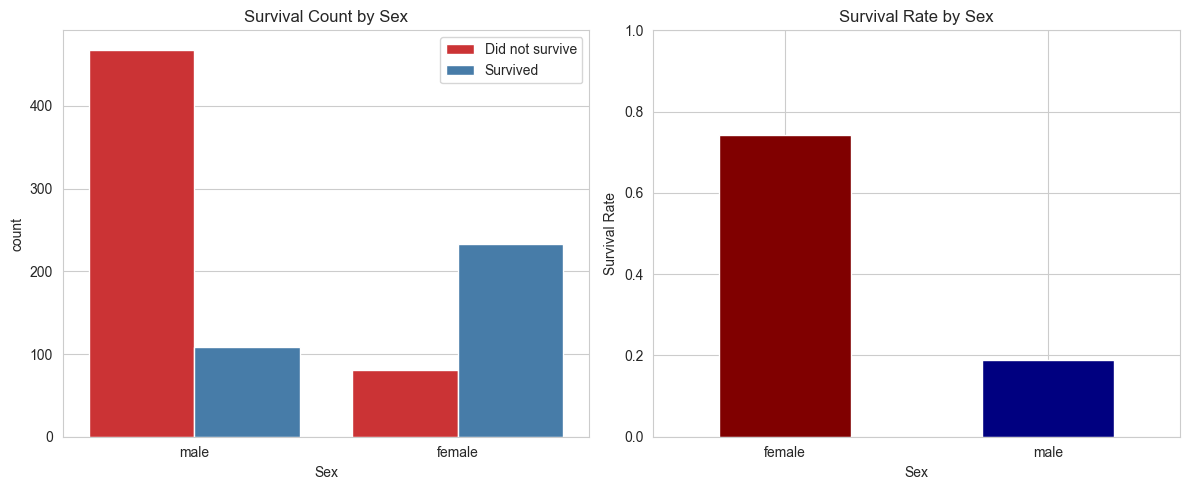

In [46]:
# Survival based on Sex

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0], palette='Set1')
axes[0].set_title('Survival Count by Sex')
axes[0].legend(['Did not survive', 'Survived'])

survival_by_sex = df.groupby('Sex')['Survived'].mean()
survival_by_sex.plot(kind='bar', ax=axes[1], color=['maroon', 'navy'], rot=0)
axes[1].set_title('Survival Rate by Sex')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../plots/survival_by_sex.png', dpi=150)
plt.show()

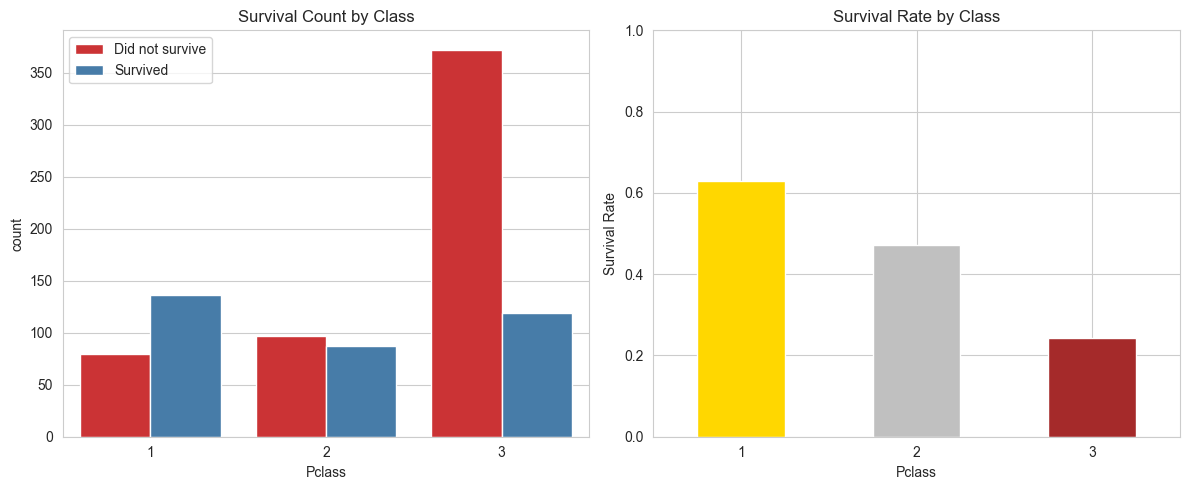

In [47]:
# Survival by Class of Passenger (Pclass)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0], palette='Set1')
axes[0].set_title('Survival Count by Class')
axes[0].legend(['Did not survive', 'Survived'])

survival_by_class = df.groupby('Pclass')['Survived'].mean()
survival_by_class.plot(kind='bar', ax=axes[1], color=['gold', 'silver', 'brown'], rot=0)
axes[1].set_title('Survival Rate by Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../plots/survival_by_class.png', dpi=150)
plt.show()

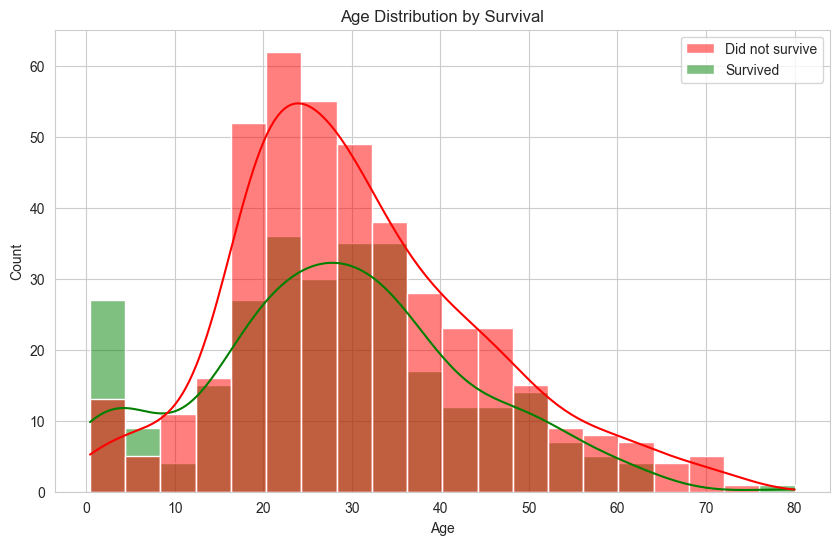

In [48]:
# Age distribution by survival

plt.figure(figsize=(10, 6))

graph = sns.histplot(data=df, x='Age', hue=df['Survived'].map({0: 'Did not survive', 1: 'Survived'}), kde=True, palette={'Did not survive': 'red', 'Survived': 'green'})

graph.legend_.set_title(None)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Survival')
plt.savefig('../plots/age_distribution.png', dpi=150)
plt.show()

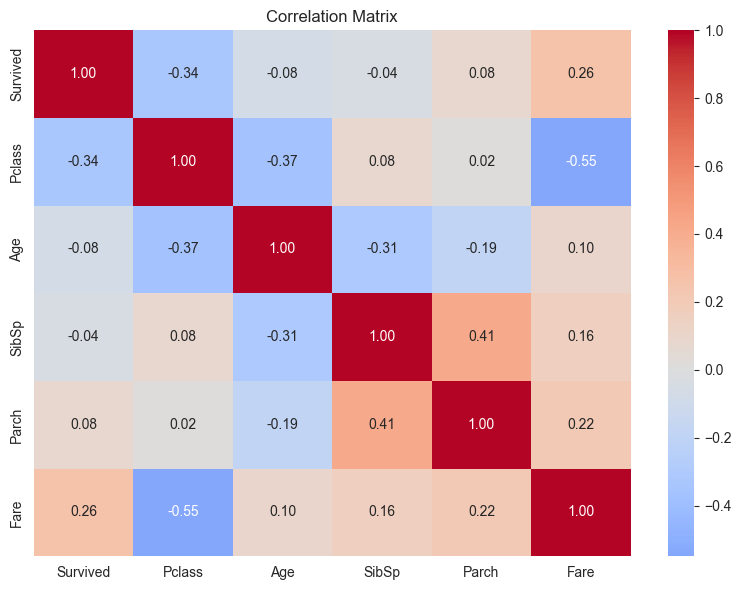

In [49]:
# Correlation heatmap of features

numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../plots/correlation_matrix.png', dpi=150)
plt.show()

### Key observations based on graphs and heatmaps

- **Sex:** The strongest predictor—females had a ~75% survival rate, while males were below 20%.
- **Pclass:** Strong negative correlation—a higher class (lower number) resulted in significantly better survival chances.
- **Age:** Clear priority for children (0–5 years). The highest mortality occurred in the 20–35 age group.
- **Missing Data:** The __Cabin__ column is mostly empty, and __Age__ also has a few blanks.